In [11]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split

In [12]:
import lime
import lime.lime_tabular

def LIME_predict_proba(ml_model, instance_to_explain):

    def predict_proba_with_names(X):
        X = pd.DataFrame(X, columns=X_train.columns)
        return ml_model.predict_proba(X)

    # Initialize the LIME Tabular Explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train.values,  # Convert DataFrame to NumPy array
        feature_names=features.columns.tolist(),  # Use actual feature names
        class_names=["0", "1"],  # Replace with your actual class labels
        discretize_continuous=True,
    )

    # Generate explanation
    explanation = explainer.explain_instance(
        instance_to_explain,
        predict_proba_with_names,  # Pass the model's probability prediction function
        num_features=10,  # Number of features to include in the explanation
    )

    # Retrieve all 10 features and their contributions
    feature_contributions = explanation.as_list()
    
    # Print each feature and its contribution value
    for feature, value in feature_contributions:
        print(f"Feature: {feature}, Value: {value}")


    # Display the explanation
    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(10, 6)  # Adjust the size to fit more features

    print("LIME f(x):", explanation.local_pred[0])

In [13]:
def LIME_binary(ml_model, instance_to_explain):

    def predict_with_names(X):
        X = pd.DataFrame(X, columns=X_train.columns)

        s = ml_model.decision_function(X)  # (n_samples,) for binary
        p1 = 1 / (1 + np.exp(-s))          # sigmoid -> (0,1)
        p0 = 1 - p1
        return np.vstack([p0, p1]).T       # sums to 1

    # Initialize the LIME Tabular Explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train.values,
        feature_names=features.columns.tolist(),
        class_names=["0", "1"],
        discretize_continuous=True,
        mode="classification",
    )

    # Generate explanation
    explanation = explainer.explain_instance(
        instance_to_explain,
        predict_with_names,   
        num_features=10,
    )

    # Retrieve all 10 features and their contributions
    feature_contributions = explanation.as_list()

    for feature, value in feature_contributions:
        print(f"Feature: {feature}, Value: {value}")

    # Display the explanation
    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(10, 6)

    print("LIME f(x):", explanation.local_pred[0])

__LIME for Base model - ALL Features (Decision Tree)__

In [14]:
df = pd.read_csv("b_all_ii.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster",axis=1)

features[["Location", "Race", "Religion"]] = (
    features[["Location", "Race", "Religion"]]
    .astype("category")
    .apply(lambda x: x.cat.codes)
)

# Split the dataset into training + development set and test set
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size = 0.2, random_state = 0)

Feature: A.BoosterPreventSpread <= 1.00, Value: 0.5497551598662396
Feature: 1.00 < Education <= 2.00, Value: 0.13201662687098642
Feature: S.AgreeMOHRecommendation <= 1.00, Value: -0.12960545301881796
Feature: 0.00 < SideEffectsAffectView <= 2.00, Value: -0.10236313828410624
Feature: C.EvidenceInsufficient <= 2.00, Value: -0.08100924495167297
Feature: 0.00 < P.EffectivenessVsRisk <= 1.00, Value: 0.07969632889013506
Feature: 0.00 < CovidPatientCare <= 1.00, Value: -0.05297073698728485
Feature: Pregnant <= 0.00, Value: -0.04909160305586812
Feature: 0.00 < AdditionalVaccines <= 1.00, Value: -0.03490596763200752
Feature: 2.00 < P.WorkDemand <= 3.00, Value: -0.026809939463575922
LIME f(x): 0.5842474802342987


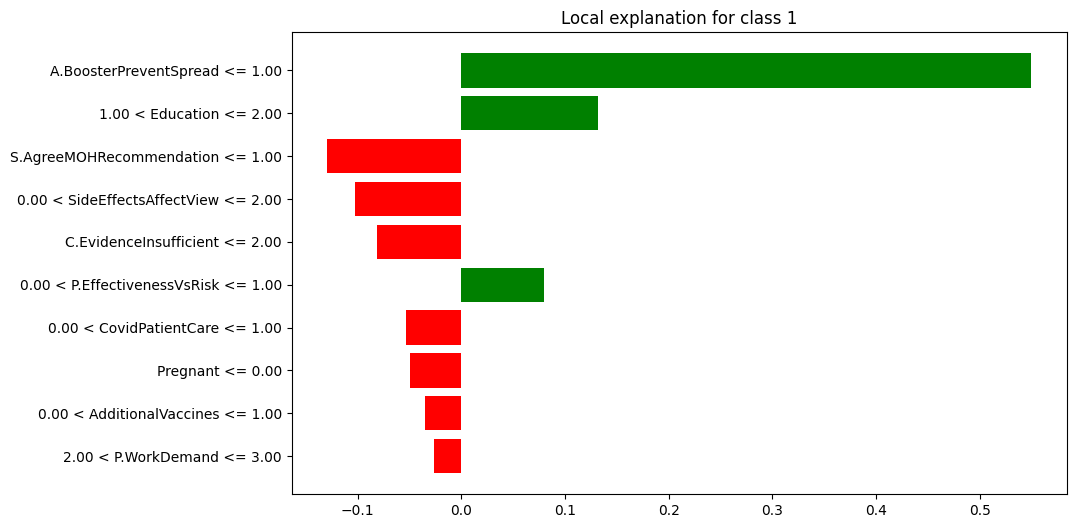

In [15]:
from sklearn.tree import DecisionTreeClassifier

# run the decision tree model

model_dt = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=0)
model_dt.fit(X_train, Y_train)

# Choose an instance from the test set
instance_to_explain = X_test.iloc[0].values  # Convert to NumPy array

LIME_predict_proba(ml_model=model_dt, instance_to_explain=instance_to_explain)

__LIME for Base model - ALL Features (SVM rbf)__

Feature: B.PreferNaturalImmunity <= 2.00, Value: -0.061640243591342785
Feature: Location <= 2.00, Value: -0.046188881110887155
Feature: C.BoosterNotNeeded <= 2.00, Value: -0.042729656862889716
Feature: A.BoosterPreventSpread <= 1.00, Value: 0.04165921572722174
Feature: 0.00 < SideEffectsAffectView <= 2.00, Value: -0.03403195358862196
Feature: C.EvidenceInsufficient <= 2.00, Value: -0.03157296568251398
Feature: P.HalalDoubt <= 2.00, Value: -0.02989850981455825
Feature: S.PreventNewVariant <= 1.00, Value: 0.02981615357296665
Feature: B.PublicRiskWithoutBooster <= 1.00, Value: 0.029168684513020793
Feature: 2.00 < P.WorkDemand <= 3.00, Value: 0.027822743511596748
LIME f(x): 0.5018495212452425


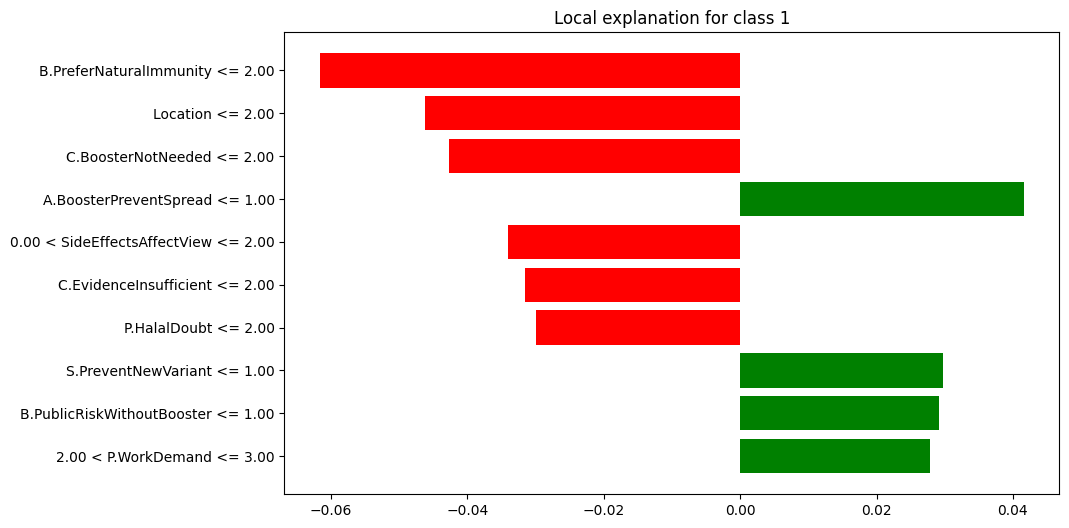

In [16]:
from sklearn.svm import SVC

# run the svm rbf model
model_svm_rbf = SVC(kernel="rbf", C= 1, gamma= "scale")
model_svm_rbf.fit(X_train, Y_train)

# Choose an instance from the test set
instance_to_explain = X_test.iloc[0].values  # Convert to NumPy array

LIME_binary(ml_model=model_svm_rbf, instance_to_explain=instance_to_explain)

__LIME for ALL Features with Anova + Chi Square (GNB)__

In [17]:
df = pd.read_csv("b_all_ac.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster",axis=1)

# Split the dataset into training + development set and test set
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size = 0.2, random_state = 0)

In [18]:
from sklearn.naive_bayes import GaussianNB

# encoder not needed because race, religion and location is not in booster anova chi dataset

model_gnb = GaussianNB()
model_gnb.fit(X_train, Y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


Feature: A.BoosterPreventSpread <= 1.00, Value: 0.21274727165314913
Feature: S.PreventNewVariant <= 1.00, Value: 0.17921118854852253
Feature: EmploymentYears > 0.49, Value: -0.1402389950757659
Feature: B.PublicRiskWithoutBooster <= 1.00, Value: 0.13824255192624058
Feature: S.AgreeMOHRecommendation <= 1.00, Value: 0.13048249099524625
Feature: A.ReturnDailyActivities <= 1.00, Value: 0.11790624969801547
Feature: C.EvidenceInsufficient <= 2.00, Value: -0.11559098655017112
Feature: S.VaccineProtectInfection <= 1.00, Value: 0.11549530551619287
Feature: S.MOHInfoTrusted <= 1.00, Value: 0.11291090558836928
Feature: B.PreferNaturalImmunity <= 2.00, Value: -0.11058297401338898
LIME f(x): 0.6470131854826174


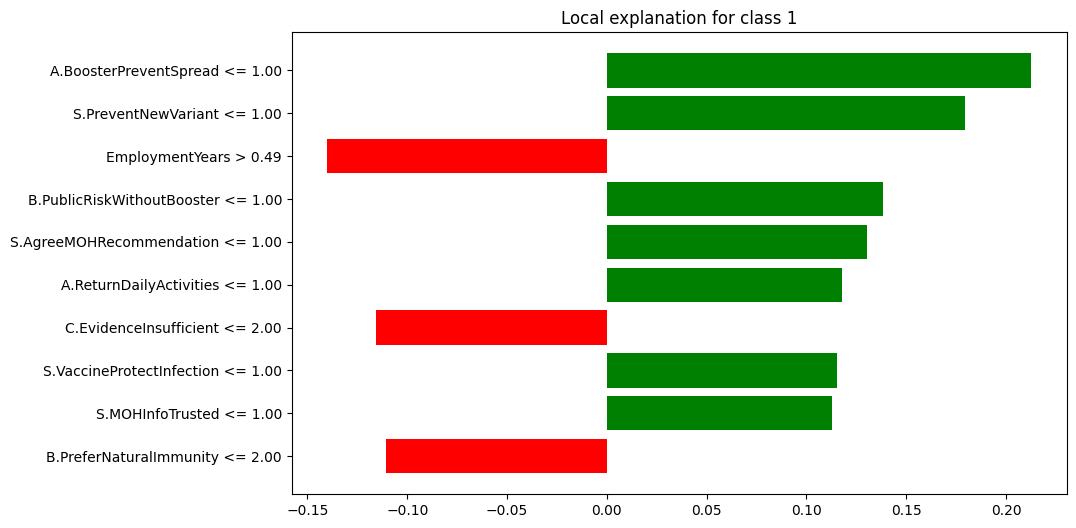

In [19]:
# Choose an instance from the test set
instance_to_explain = X_test.iloc[0].values  # Convert to NumPy array

LIME_predict_proba(ml_model=model_gnb, instance_to_explain=instance_to_explain)

__LIME for Base model - Aggregated (Bagging - SVM poly)__

Feature: 0.00 < AdditionalVaccines <= 1.00, Value: -0.10783558214174072
Feature: C_mean <= 0.86, Value: 0.09133626345082206
Feature: 0.00 < SideEffectsAffectView <= 2.00, Value: -0.08857658756762256
Feature: Race <= 2.00, Value: 0.08027861692043306
Feature: 1.00 < Income <= 2.00, Value: -0.0769888378272003
Feature: 0.00 < VaccinationSideEffects <= 1.00, Value: 0.04213264897192671
Feature: 0.00 < CovidPatientCare <= 1.00, Value: -0.03525275296553706
Feature: 0.00 < CovidInfected <= 1.00, Value: -0.03352572730189213
Feature: Pregnant <= 0.00, Value: -0.025824472652582857
Feature: Age > 0.72, Value: -0.023836009500433856
LIME f(x): 0.43269312005310906


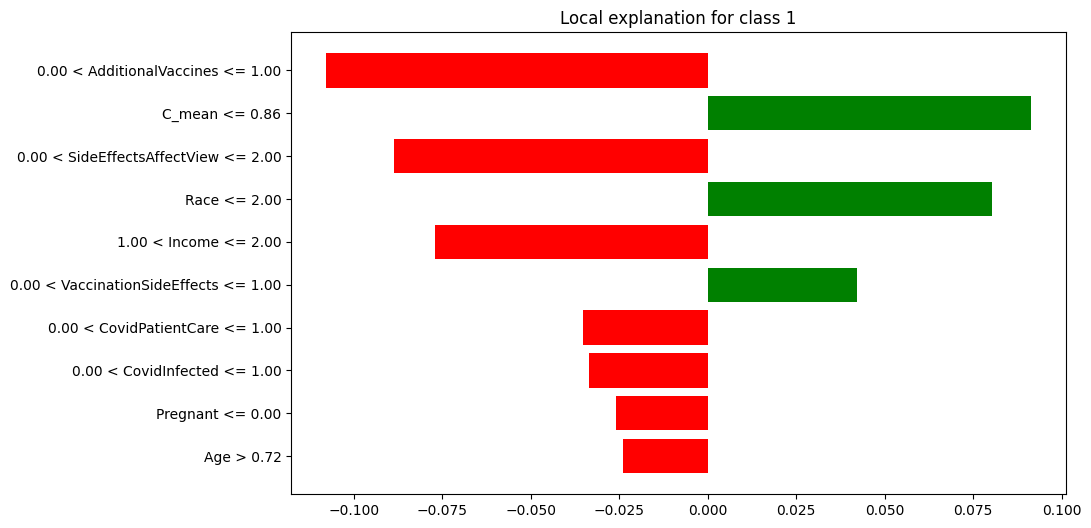

In [21]:
from sklearn.ensemble import BaggingClassifier

df = pd.read_csv("b_avg_all_ii.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster", axis=1)

features[["Location", "Race", "Religion"]] = (
    features[["Location", "Race", "Religion"]]
    .astype("category")
    .apply(lambda x: x.cat.codes)
)

# Split the dataset into training + development set and test set
X_train, X_test, Y_train, Y_test = train_test_split(
    features, target, test_size=0.2, random_state=0
)

from sklearn.svm import SVC

# run the SVM poly model
model_svm_poly = SVC(
    C=1,
    kernel='poly',
    degree=2,
    gamma='scale',
    probability=True,
    random_state=0
)

# bagging with SVM poly
model_bagging_svm_poly = BaggingClassifier(
    estimator=model_svm_poly,
    n_estimators=10,
    random_state=0
)

model_bagging_svm_poly.fit(X_train, Y_train)

# Choose an instance from the test set
instance_to_explain = X_test.iloc[0].values  # Convert to NumPy array

LIME_predict_proba(ml_model=model_bagging_svm_poly, instance_to_explain=instance_to_explain)

__LIME for Aggregated Features with Anova + Chi Square (Boosting)__

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

df = pd.read_csv("b_avg_ac.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster",axis=1)

# encoder is not needed because race, religion and location is not in dataset for aggregated anova chi

# Split the dataset into training + development set and test set
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size = 0.2, random_state = 0)

model_boosting_ac = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_boosting_ac.fit(X_train, Y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

Feature: Age > 0.72, Value: -0.2996317791731534
Feature: 0.00 < SideEffectsAffectView <= 2.00, Value: -0.22530620559986517
Feature: C_mean <= 0.86, Value: 0.1289262574379587
Feature: 1.00 < Education <= 2.00, Value: 0.06381017519025194
Feature: EmploymentYears > 0.49, Value: -0.06369969634767016
Feature: 1.40 < D_mean <= 1.80, Value: 0.023265265279734316
Feature: 0.60 < A_mean <= 1.00, Value: 0.01650459015484523
Feature: 2.20 < E_mean <= 2.60, Value: -0.00893899153238413
LIME f(x): 0.3190385665115521


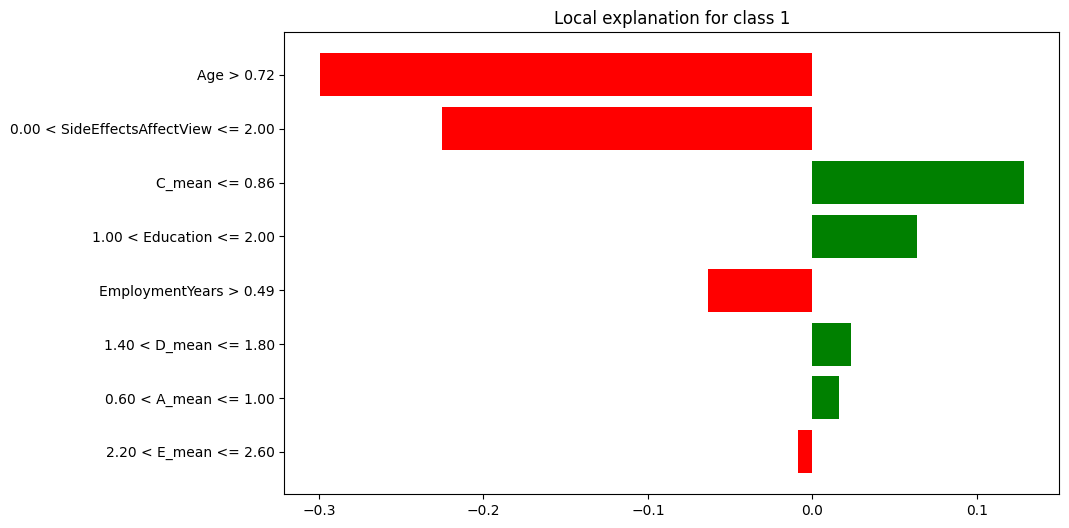

In [23]:
# Choose an instance from the test set
instance_to_explain = X_test.iloc[0].values  # Convert to NumPy array

LIME_binary(ml_model=model_boosting_ac, instance_to_explain=instance_to_explain)

__LIME for Aggregated Features with Anova + Chi Square (GNB)__

In [24]:
model_gnb_ac = GaussianNB()
model_gnb_ac.fit(X_train, Y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


Feature: EmploymentYears > 0.49, Value: -0.24366438324861828
Feature: C_mean <= 0.86, Value: 0.19202721242980814
Feature: 0.00 < SideEffectsAffectView <= 2.00, Value: -0.14695351704332385
Feature: Age > 0.72, Value: -0.11355187319560532
Feature: 0.60 < A_mean <= 1.00, Value: 0.07579335446919955
Feature: 1.00 < Education <= 2.00, Value: -0.047864024075612806
Feature: 2.20 < E_mean <= 2.60, Value: 0.02248437419487285
Feature: 1.40 < D_mean <= 1.80, Value: 0.005300060322887739
LIME f(x): 0.34479846511766443


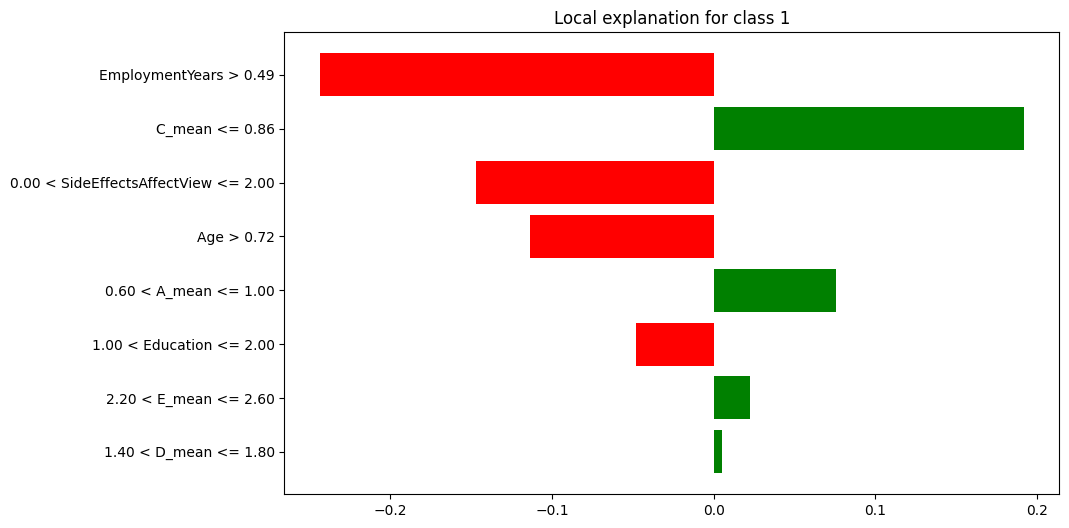

In [25]:
# Choose an instance from the test set
instance_to_explain = X_test.iloc[0].values  # Convert to NumPy array

LIME_predict_proba(ml_model=model_gnb_ac, instance_to_explain=instance_to_explain)